In [111]:
import pandas as pd

In [112]:
df_annotate = pd.read_csv("preprocessed_data_s2.csv")
df_annotate

,Unnamed: 0,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,...,agreement_is_noise_or_spam_text,agreement_related_to_election_2024,agreement_toxicity,agreement_polarized,agreement_profanity_obscenity,agreement_threat_incitement_to_violence,agreement_insults,agreement_identity_attack,agreement_sexually_explicit,cleaned_text
0,2,1-100,"['7', '15', '32']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,...,True,False,False,True,True,True,False,True,True,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
1,19,1-1015,"['10', '18', '32']",Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,...,True,False,True,True,True,True,False,False,True,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
2,20,1-1016,"['10', '18']",Video “Tentara Cina Komunis Tiongkok Masuk Ind...,Akun Facebook Imho Walleye (fb.com/10001818281...,Tionghoa,0,0,1,1,...,True,True,True,True,True,True,False,False,True,Video “Tentara Cina Komunis Tiongkok Masuk Ind...
3,25,1-1020,"['10', '18', '32']",Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...,” Rezim Jokowi Menganggap Mereka seperti Teror...,UNKNOWN,0,0,1,1,...,True,True,True,True,True,True,False,True,True,Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...
4,26,1-1021,"['10', '18']",GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...,“BERSIAPLAH INDONESIA AKAN DI MISKINKAN TERNYA...,UNKNOWN,0,1,1,1,...,True,True,True,True,False,True,False,True,True,GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,28369,4-928,"['19', '18']",@tanyakanrl Salah satu kejahatan dari houthi s...,NaN,Syiah,0,0,1,1,...,True,True,True,True,True,True,True,True,True,@tanyakanrl Salah satu kejahatan dari houthi s...
1964,28385,4-942,['19'],@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,...,True,True,True,True,True,True,True,True,True,@Heraloebss Usir Rohingya dari Aceh dan seluru...
1965,28390,4-947,['19'],Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,...,True,True,True,True,True,True,True,True,True,Bismillah... Semoga orang yang mati‑mati membe...
1966,28406,4-961,"['19', '18']","Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,...,True,True,True,True,True,False,True,False,True,"Gila ya, kalau umat bersatu habis juga itu ger..."


In [113]:
df_annotate.drop(columns =['Unnamed: 0', 'agreement_is_noise_or_spam_text', 'agreement_related_to_election_2024',
        'agreement_toxicity','agreement_polarized', 'agreement_profanity_obscenity', 'agreement_threat_incitement_to_violence',
        'agreement_insults','agreement_identity_attack', 'agreement_sexually_explicit'], inplace = True)

In [114]:
df_annotate.columns.to_list()

['text_id',
 'annotators_id',
 'text',
 'initial_paragraph',
 'topic',
 'is_noise_or_spam_text',
 'related_to_election_2024',
 'toxicity',
 'polarized',
 'profanity_obscenity',
 'threat_incitement_to_violence',
 'insults',
 'identity_attack',
 'sexually_explicit',
 'cleaned_text']

In [115]:
df_annotator = pd.read_csv("annotator_demographic.csv")
df_annotator

,annotator_id,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,1,Tionghoa,Kristen,no,no,F,50,Jakarta,Diploma,Bekerja,2
1,2,Madura,Islam,no,no,F,22,Madura,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,3,Batak,Kepercayaan Lokal,no,no,F,29,Medan,Sarjana (S1),Bekerja,3
3,4,Bali,Hindu,no,no,M,23,Bandung,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,-
4,5,Jawa,Syiah,no,no,M,46,Bandung,Diploma,Bekerja,Golput
5,6,Minang,Ahmadiyah,no,no,F,22,Jakarta,Sarjana (S1),Bekerja,3
6,7,Minang,Islam,yes,no,F,27,Padang,Sarjana (S1),Bekerja,1
7,8,Arab,Islam,no,no,M,23,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,1
8,9,Jawa,Islam,no,no,F,21,Magelang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,2
9,10,Tionghoa,Buddha,no,no,F,20,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3


In [116]:
annotate_columns = df_annotate.drop(['annotators_id', 'text_id'], axis=1).columns.to_list()
annotator_columns = df_annotator.drop(['annotator_id'], axis=1).columns.to_list()

In [117]:
import ast

df_annotate["annotators_id"] = df_annotate["annotators_id"].apply(
    ast.literal_eval
)

df_annotate

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text
0,1-100,"[7, 15, 32]",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
1,1-1015,"[10, 18, 32]",Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,0,0,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
2,1-1016,"[10, 18]",Video “Tentara Cina Komunis Tiongkok Masuk Ind...,Akun Facebook Imho Walleye (fb.com/10001818281...,Tionghoa,0,0,1,1,0,0,0,0,0,Video “Tentara Cina Komunis Tiongkok Masuk Ind...
3,1-1020,"[10, 18, 32]",Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...,” Rezim Jokowi Menganggap Mereka seperti Teror...,UNKNOWN,0,0,1,1,0,0,0,1,0,Jokowi Bebaskan Pajak Selama 120 Tahun untuk W...
4,1-1021,"[10, 18]",GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...,“BERSIAPLAH INDONESIA AKAN DI MISKINKAN TERNYA...,UNKNOWN,0,1,1,1,0,0,0,0,0,GAMBAR GANJAR PRANOWO BERSALAMAN DENGAN PRESID...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,4-928,"[19, 18]",@tanyakanrl Salah satu kejahatan dari houthi s...,NaN,Syiah,0,0,1,1,0,0,0,1,0,@tanyakanrl Salah satu kejahatan dari houthi s...
1964,4-942,[19],@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,1,0,@Heraloebss Usir Rohingya dari Aceh dan seluru...
1965,4-947,[19],Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,1,0,Bismillah... Semoga orang yang mati‑mati membe...
1966,4-961,"[19, 18]","Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger..."


In [118]:
df_annotate_exp = df_annotate.explode("annotators_id")
df_annotate_exp = df_annotate_exp.rename(
    columns={"annotators_id": "annotator_id"}
)
df_annotate_exp

,text_id,annotator_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text
0,1-100,7,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
0,1-100,15,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
0,1-100,32,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,0,0,Gini aja deh @KPU_ID usul nih. Gimana kalau mi...
1,1-1015,10,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,0,0,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
1,1-1015,18,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,0,0,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,4-942,19,@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,1,0,@Heraloebss Usir Rohingya dari Aceh dan seluru...
1965,4-947,19,Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,1,0,Bismillah... Semoga orang yang mati‑mati membe...
1966,4-961,19,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger..."
1966,4-961,18,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger..."


In [119]:
df_annotate_exp["annotator_id"] = df_annotate_exp["annotator_id"].astype(str)
df_annotator["annotator_id"] = df_annotator["annotator_id"].astype(str)

In [120]:
df = df_annotate_exp.merge(
    df_annotator,
    on="annotator_id",
    how="left"
)
df = df.drop(['text_id', 'annotator_id'], axis=1)
df

,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,...,ethnicity,religion,disability,lgbt,gender,age,domisili,pendidikan terakhir,status pekerjaan,president vote leaning
0,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,...,Minang,Islam,yes,no,F,27.0,Padang,Sarjana (S1),Bekerja,1
1,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,...,Tionghoa,Katolik,yes,no,F,21.0,Jakarta,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
2,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,0,0,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,...,Tionghoa,Buddha,no,no,F,20.0,Tangerang,Sekolah Menengah Atas (SMA),Pelajar/Mahasiswa,3
4,Pesan Berantai “RENCANA BUSUK PEMBUNUHAN MASSA...,"NARASI: “JAGA² SAJA,JIKA DOKTER² MAU SUNTIK KI...",Tionghoa,0,0,1,1,0,0,0,...,Bali,Hindu,yes,no,M,34.0,Jakarta,Magister (S2),Tidak Bekerja,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5712,@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,...,Batak,Kristen,no,no,F,39.0,Depok,Magister (S2),Bekerja,2
5713,Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,...,Batak,Kristen,no,no,F,39.0,Depok,Magister (S2),Bekerja,2
5714,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,...,Batak,Kristen,no,no,F,39.0,Depok,Magister (S2),Bekerja,2
5715,"Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,...,Bali,Hindu,yes,no,M,34.0,Jakarta,Magister (S2),Tidak Bekerja,2


#Preprocessing

In [121]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "lu": "kamu",
    "loe": "kamu",
    "gw": "saya",
    "gue": "saya",
    "bgt": "banget",
    "dgn": "dengan",
    "krn": "karena",
    "aja": "saja",
    "trs": "terus"
}

In [122]:
import re

def normalize_slang(text, slang_dict):
    words = text.split()
    return " ".join([slang_dict.get(w.lower(), w) for w in words])

def preprocess_text(text, slang_dict, lowercase=True):
    if not isinstance(text, str):
        return ""

    # 1. remove username (@user)
    text = re.sub(r'@\w+', '', text)

    # 2. remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. remove unwanted symbols (keep .,!?)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # 5. normalize slang
    text = normalize_slang(text, slang_dict)

    # 6. normalize repeated chars (contoh: anjiiing → anjiing)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. lowercase (optional)
    if lowercase:
        text = text.lower()

    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [165]:
from tqdm import tqdm
tqdm.pandas()

df["processed_text"] = (
    df["cleaned_text"]
    .fillna("")
    .astype(str)
    .progress_apply(
        lambda x: preprocess_text(x, slang_dict)
    )
)

100%|██████████| 5717/5717 [00:00<00:00, 6179.65it/s]


#Modeling

In [124]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

In [125]:
x = df.drop(columns=['toxicity'])
y = df['toxicity']

In [166]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [167]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

In [128]:
print(dataset["train"].column_names)

['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', '__index_level_0__']


In [168]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in annotator_columns:

    le = LabelEncoder()

    df[col] = df[col].astype(str)

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [169]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

def tokenize(batch):

    tokenized = tokenizer(
        batch["processed_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

    # metadata fusion
    tokenized["metadata"] = [
        [
            batch[col][i]
            for col in annotator_columns
        ]
        for i in range(len(batch["processed_text"]))
    ]

    # rename label -> labels
    tokenized["labels"] = batch["toxicity"]

    return tokenized

In [170]:
tokenized_datasets_1 = dataset.map(
    tokenize,
    batched=True
)
print(tokenized_datasets_1)

Map:   0%|          | 0/4573 [00:00<?, ? examples/s]

Map:   0%|          | 0/1144 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'metadata', 'labels'],
        num_rows: 4573
    })
    test: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning'

In [171]:
tokenized_datasets_1.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "metadata",
        "labels"
    ]
)

print(tokenized_datasets_1['train']['metadata'])

Column([tensor([ 0,  3,  1,  1,  0, 16,  0,  1,  0,  3]), tensor([ 0,  3,  1,  1,  0, 16,  0,  1,  0,  3]), tensor([11,  3,  1,  1,  1, 19,  6,  2,  0,  2]), tensor([ 6,  7,  1,  1,  2, 20,  3,  0,  0,  4]), tensor([11,  3,  1,  1,  1, 19,  6,  2,  0,  2])])


In [172]:
import torch
import torch.nn as nn

from transformers import AutoModel

class IndoBERTFusion(nn.Module):

    def __init__(
        self,
        num_metadata_features,
        num_labels
    ):

        super().__init__()

        # =========================
        # TEXT ENCODER
        # =========================

        self.bert = AutoModel.from_pretrained(
            "indolem/indobertweet-base-uncased"
        )

        hidden_size = self.bert.config.hidden_size
        # 768

        # =========================
        # METADATA ENCODER
        # =========================

        self.metadata_encoder = nn.Sequential(

            nn.Linear(num_metadata_features, 32),
            nn.ReLU(),
            nn.Dropout(0.2)

        )

        # =========================
        # CLASSIFIER
        # =========================

        self.classifier = nn.Sequential(

            nn.Linear(hidden_size + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_labels)

        )

    def forward(
        self,
        input_ids,
        attention_mask,
        metadata,
        labels=None
    ):

        # =========================
        # BERT OUTPUT
        # =========================

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # CLS embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        # shape = [batch_size, 768]

        # =========================
        # METADATA EMBEDDING
        # =========================

        metadata_vector = self.metadata_encoder(
            metadata.float()
        )

        # =========================
        # FUSION
        # =========================

        fused = torch.cat(
            [cls_embedding, metadata_vector],
            dim=1
        )

        # =========================
        # CLASSIFICATION
        # =========================

        logits = self.classifier(fused)

        loss = None

        if labels is not None:

            loss_fn = nn.CrossEntropyLoss()

            loss = loss_fn(
                logits,
                labels
            )

        return {
            "loss": loss,
            "logits": logits
        }

In [173]:
model_s1 = IndoBERTFusion(
    num_metadata_features=len(annotator_columns),
    num_labels=2
)

print(len(annotator_columns))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


10


In [174]:
sample = tokenized_datasets_1["train"][0]

print(sample)

{'input_ids': tensor([    3,  7989, 12613,  8215,   932,  3867,  6071,   936,  1581,  4746,
         8131, 22025,    16,  2641,  3273, 12596,     4,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

In [175]:
batch = {
    "input_ids": sample["input_ids"].unsqueeze(0),
    "attention_mask": sample["attention_mask"].unsqueeze(0),
    "metadata": sample["metadata"].unsqueeze(0),
    "labels": sample["labels"].unsqueeze(0)
}

output = model_s1(**batch)

print(output["logits"].shape)

torch.Size([1, 2])


In [176]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
def compute_metrics_s1(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [177]:
from transformers import TrainingArguments, Trainer

args_s1 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s1 = Trainer(
    model=model_s1,
    args=args_s1,
    train_dataset=tokenized_datasets_1["train"],
    eval_dataset=tokenized_datasets_1["test"],
    compute_metrics=compute_metrics_s1
)

In [178]:
trainer_s1.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.001816,0.047213,0.991259,0.995610
2,0.000978,0.037058,0.993007,0.996482
3,0.000724,0.032075,0.995629,0.997798
4,0.006208,0.032607,0.995629,0.997798
5,0.000261,0.033412,0.995629,0.997798


TrainOutput(global_step=2860, training_loss=0.031381207783788403, metrics={'train_runtime': 818.0685, 'train_samples_per_second': 27.95, 'train_steps_per_second': 3.496, 'total_flos': 0.0, 'train_loss': 0.031381207783788403, 'epoch': 5.0})

In [179]:
history = trainer_s1.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = [x['epoch'] for x in history if 'eval_loss' in x]

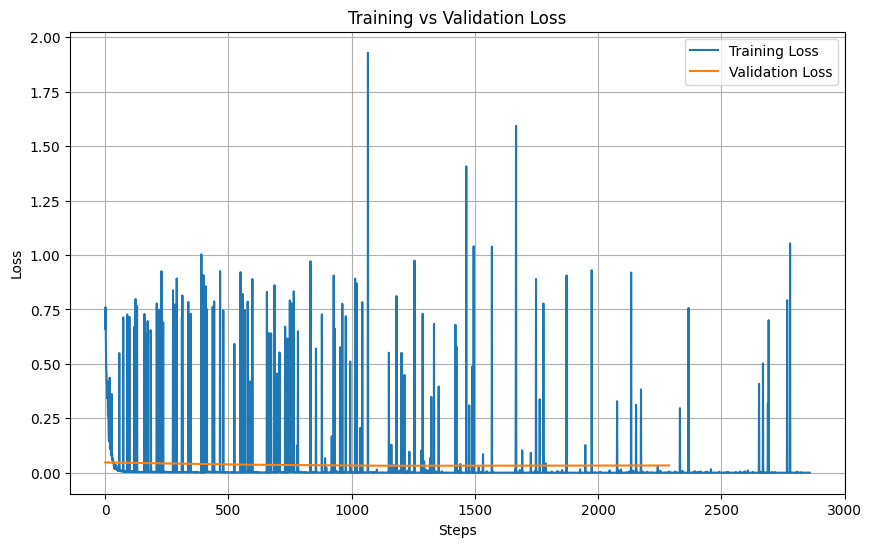

In [180]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [181]:
evaluation_results1 = trainer_s1.evaluate()
print(evaluation_results1)

{'eval_loss': 0.032075390219688416, 'eval_accuracy': 0.9956293706293706, 'eval_f1': 0.9977983267283135, 'eval_runtime': 8.1616, 'eval_samples_per_second': 140.169, 'eval_steps_per_second': 17.521, 'epoch': 5.0}


In [182]:
pred1 = trainer_s1.predict(tokenized_datasets_1["test"])
pred_label1 = pred1.predictions.argmax(axis=1)

y_test_numeric = test_df['toxicity']

print(classification_report(y_test_numeric, pred_label1))

              precision    recall  f1-score   support

           0       0.86      0.60      0.71        10
           1       1.00      1.00      1.00      1134

    accuracy                           1.00      1144
   macro avg       0.93      0.80      0.85      1144
weighted avg       1.00      1.00      1.00      1144



##Stage 2

In [183]:
def add_polarization_text(row):
    return f"[POL={row['polarized']}] {row['processed_text']}"

df["text_with_pol"] = df.apply(add_polarization_text, axis=1)

In [184]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

X = df["text_with_pol"]
y2 = df[LABEL_COLS]

In [185]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [186]:
train_dataset_2 = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset_2 = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

dataset_2 = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

In [187]:
print(dataset_2)

DatasetDict({
    train: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', 'text_with_pol', '__index_level_0__'],
        num_rows: 4573
    })
    test: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', 'text_with_pol', '__index_level_0_

In [188]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

def tokenize_multilabel(batch):

    tokenized = tokenizer(
        batch["text_with_pol"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

    # metadata fusion
    tokenized["metadata"] = [
        [
            batch[col][i]
            for col in annotator_columns
        ]
        for i in range(len(batch["text_with_pol"]))
    ]

    # rename label -> labels
    tokenized["labels"] = [
        [
            batch[col][i]
            for col in LABEL_COLS
        ]
        for i in range(len(batch["text_with_pol"]))
    ]

    return tokenized

In [189]:
tokenized_datasets_2 = dataset_2.map(
    tokenize_multilabel,
    batched=True
)
print(tokenized_datasets_2)

Map:   0%|          | 0/4573 [00:00<?, ? examples/s]

Map:   0%|          | 0/1144 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', 'text_with_pol', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'metadata', 'labels'],
        num_rows: 4573
    })
    test: Dataset({
        features: ['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'presid

In [190]:
print(tokenized_datasets_2["train"].column_names)

['text', 'initial_paragraph', 'topic', 'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity', 'polarized', 'profanity_obscenity', 'threat_incitement_to_violence', 'insults', 'identity_attack', 'sexually_explicit', 'cleaned_text', 'ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning', 'processed_text', 'text_with_pol', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'metadata', 'labels']


In [191]:
tokenized_datasets_2.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "metadata",
        "labels"
    ]
)
print(tokenized_datasets_2["train"][0])

{'input_ids': tensor([    3,    37,     1,    33,    21,    39,  1766,  4183,  4324, 24077,
         1634, 25224,  8110,   939,  3026, 13185,  1485,  1718,     4,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

In [192]:
import torch
import torch.nn as nn

from transformers import AutoModel


class IndoBERTFusionMultiLabel(nn.Module):

    def __init__(
        self,
        num_metadata_features,
        num_labels=5
    ):

        super().__init__()

        # =========================
        # TEXT ENCODER
        # =========================

        self.bert = AutoModel.from_pretrained(
            "indolem/indobertweet-base-uncased"
        )

        hidden_size = self.bert.config.hidden_size
        # 768

        # =========================
        # METADATA ENCODER
        # =========================

        self.metadata_encoder = nn.Sequential(

            nn.Linear(num_metadata_features, 32),
            nn.ReLU(),
            nn.Dropout(0.2)

        )

        # =========================
        # CLASSIFIER
        # =========================

        self.classifier = nn.Sequential(

            nn.Linear(hidden_size + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_labels)

        )

    def forward(
        self,
        input_ids,
        attention_mask,
        metadata,
        labels=None
    ):

        # =========================
        # BERT OUTPUT
        # =========================

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        # [batch_size, 768]

        # =========================
        # METADATA EMBEDDING
        # =========================

        metadata_vector = self.metadata_encoder(
            metadata.float()
        )

        # =========================
        # FUSION
        # =========================

        fused = torch.cat(
            [cls_embedding, metadata_vector],
            dim=1
        )

        # =========================
        # CLASSIFICATION
        # =========================

        logits = self.classifier(fused)
        # shape = [batch_size, 5]

        loss = None

        if labels is not None:

            loss_fn = nn.BCEWithLogitsLoss()

            loss = loss_fn(
                logits,
                labels.float()
            )

        return {
            "loss": loss,
            "logits": logits
        }

In [193]:
model_s2 = IndoBERTFusionMultiLabel(
    num_metadata_features=len(annotator_columns),
    num_labels=len(LABEL_COLS)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [194]:
import numpy as np

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss
)

import torch


def compute_metrics_s2(eval_pred):

    logits, labels = eval_pred

    # sigmoid
    probs = torch.sigmoid(
        torch.tensor(logits)
    ).numpy()

    # threshold
    preds = (probs >= 0.5).astype(int)

    metrics = {

        # exact match ratio
        "accuracy": accuracy_score(labels, preds),

        # micro
        "f1_micro": f1_score(
            labels,
            preds,
            average="micro",
            zero_division=0
        ),

        "precision_micro": precision_score(
            labels,
            preds,
            average="micro",
            zero_division=0
        ),

        "recall_micro": recall_score(
            labels,
            preds,
            average="micro",
            zero_division=0
        ),

        # macro
        "f1_macro": f1_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        ),

        # multilabel metric
        "hamming_loss": hamming_loss(
            labels,
            preds
        )
    }

    return metrics

In [195]:
from transformers import TrainingArguments

args_s2 = TrainingArguments(
    output_dir="./model_toxicity_s2",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s2 = Trainer(
    model=model_s2,
    args=args_s2,
    train_dataset=tokenized_datasets_2["train"],
    eval_dataset=tokenized_datasets_2["test"],
    compute_metrics=compute_metrics_s2
)

In [196]:
trainer_s2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,Precision Micro,Recall Micro,F1 Macro,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.266960,0.280237,0.532343,0.535714,0.697026,0.435035,0.258323,0.113636,8.560900,133.631000,16.704000
2,0.147953,0.221144,0.659091,0.691327,0.767705,0.628770,0.462546,0.084615,8.677300,131.839000,16.480000
3,0.152993,0.185555,0.736888,0.764450,0.823293,0.713457,0.589024,0.066259,8.678200,131.825000,16.478000
4,0.537486,0.171380,0.761364,0.791872,0.843832,0.745940,0.626974,0.059091,8.704800,131.422000,16.428000
5,0.080175,0.167021,0.777098,0.801220,0.844473,0.762181,0.634797,0.056993,8.512300,134.394000,16.799000


TrainOutput(global_step=2860, training_loss=0.22055594170322784, metrics={'train_runtime': 925.6226, 'train_samples_per_second': 24.702, 'train_steps_per_second': 3.09, 'total_flos': 0.0, 'train_loss': 0.22055594170322784, 'epoch': 5.0})

In [197]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import numpy as np
import torch


def show_multilabel_confusion_matrix(
    trainer,
    dataset,
    label_names,
    threshold=0.5
):

    # prediction
    predictions = trainer.predict(dataset)

    logits = predictions.predictions
    labels = predictions.label_ids

    # sigmoid
    probs = torch.sigmoid(
        torch.tensor(logits)
    ).numpy()

    preds = (probs >= threshold).astype(int)

    # one confusion matrix per label
    for i, label_name in enumerate(label_names):

        cm = confusion_matrix(
            labels[:, i],
            preds[:, i]
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        plt.figure(figsize=(5,5))

        disp.plot()

        plt.title(label_name)

        plt.show()

<Figure size 500x500 with 0 Axes>

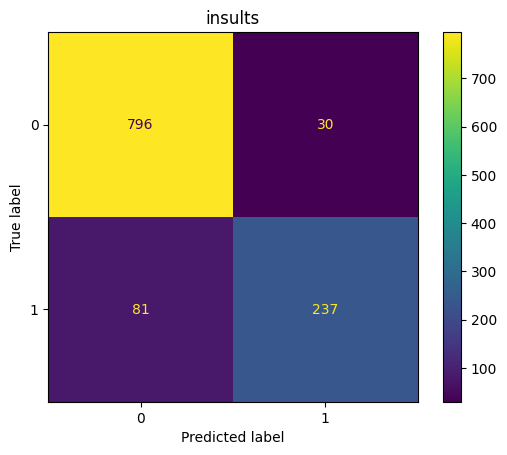

<Figure size 500x500 with 0 Axes>

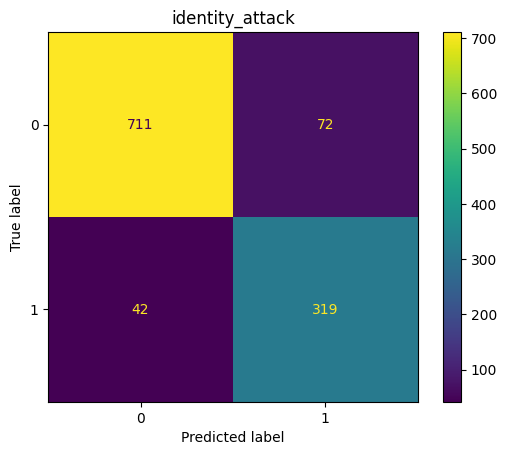

<Figure size 500x500 with 0 Axes>

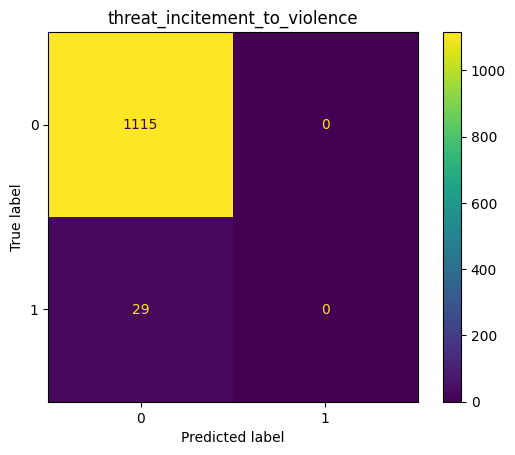

<Figure size 500x500 with 0 Axes>

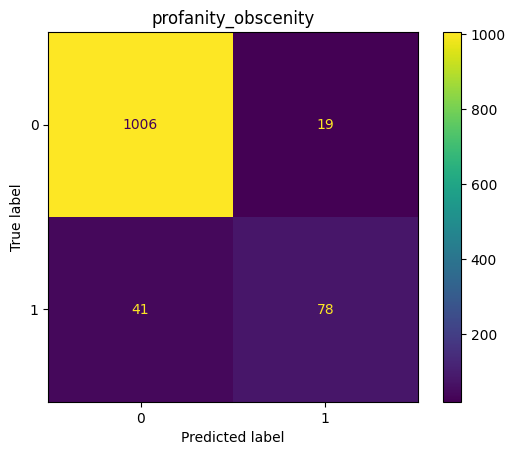

<Figure size 500x500 with 0 Axes>

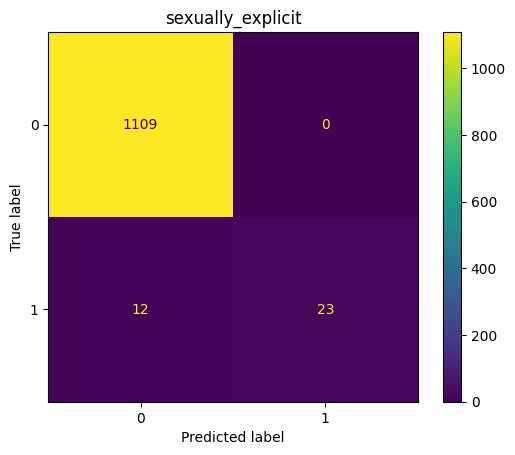

In [198]:
show_multilabel_confusion_matrix(
    trainer=trainer_s2,
    dataset=tokenized_datasets_2["test"],
    label_names=LABEL_COLS
)

In [199]:
import torch


def predict_toxic_labels(
    text,
    metadata_values,
    model,
    tokenizer,
    label_names,
    threshold=0.5
):

    model.eval()

    device = next(model.parameters()).device

    # =========================
    # TOKENIZATION
    # =========================

    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # move tensors to GPU
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # =========================
    # METADATA
    # =========================

    metadata_tensor = torch.tensor(
        [metadata_values],
        dtype=torch.float
    ).to(device)

    # =========================
    # INFERENCE
    # =========================

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            metadata=metadata_tensor
        )

    logits = outputs["logits"]

    # =========================
    # SIGMOID
    # =========================

    probs = torch.sigmoid(
        logits
    ).cpu().numpy()[0]

    preds = (probs >= threshold).astype(int)

    # =========================
    # OUTPUT
    # =========================

    print("TEXT:")
    print(text)

    print("\nPREDICTIONS:")

    for i, label in enumerate(label_names):

        print(
            f"{label}: "
            f"{preds[i]} "
            f"(prob={probs[i]:.4f})"
        )

In [200]:
print(len(annotator_columns))
print(annotator_columns)

10
['ethnicity', 'religion', 'disability', 'lgbt', 'gender', 'age', 'domisili', 'pendidikan terakhir', 'status pekerjaan', 'president vote leaning']


In [201]:
sample_text = "[POL=1] dasar goblok lu"

sample_metadata = [
    1,  # ethnicity
    0,  # religion
    1,  # disability
    0,  # lgbt
    1,  # gender
    2,  # age
    1,  # domisili
    0,  # pendidikan
    1,  # pekerjaan
    0   # political leaning
]

predict_toxic_labels(
    text=sample_text,
    metadata_values=sample_metadata,
    model=model_s2,
    tokenizer=tokenizer,
    label_names=LABEL_COLS
)

TEXT:
[POL=1] dasar goblok lu

PREDICTIONS:
insults: 0 (prob=0.2490)
identity_attack: 1 (prob=0.5088)
threat_incitement_to_violence: 0 (prob=0.0085)
profanity_obscenity: 0 (prob=0.2112)
sexually_explicit: 0 (prob=0.0062)
